# Processed Disdrometer Data

Two steps, need to merge the perpendicular disdrometers based on wind direction. Need to reprocess raw data to include the size distribution and fall velocity distribution data. Code to reprocess raw data handed off to data ingest team. Here we merge based on lidar data at each station.

1. Find when dates for disdrometers and lidars overlap
2. Ensure data quality
3. Merge based on wind direction
4. Recheck data quality
5. At NANT there is only a N-S disdrometer. Compare degredation in measurement when wind direction not aligned with ASIT and BARG dataset. Use windspeed as well, compare low and high wind speeds. Maybe trust when windspeeds low and not when high. Attempt to estimate an improved product. Likely not scientific. There is already so much variability in precipitation measurements.

In [1]:
import dask
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
import matplotlib.axes as maxes
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
from windrose import WindroseAxes
from io import BytesIO
import warnings
from datetime import datetime, timedelta
import xarray as xr
import glob
warnings.filterwarnings('ignore')

# 1. Load Datasets

Found at Wind Data Hub. Downloaded Many Datasets. Especially the wind datasets. These were the ones I found that had the best QC'd wind products in my opinion. I tried to find ones with surface winds. At the very least, all three of these have winds at 100m, which would be equal comparison. At least at ASIT there is surface winds.

In [2]:
# Define datasets to load: (name, glob_pattern, variable, height_level, y_offset, color)
datasets_config = [
    ('Nant Winds', '/qfs/people/gold396/ORACLE/wfip3/nant.lidar.10min.z01.c1/*', 'wd', 100, 1.0, 'blue'),
    ('Nant Rain', '/qfs/people/gold396/ORACLE/wfip3/nant.ld.z01.b1/*', 'rain_intensity', None, 0.5, 'blue'),
    ('Asit Winds', '/qfs/people/gold396/ORACLE/wfip3/asit.lidar.z01.a0/*', 'horizontal_wind_direction', 97, 0.0, 'orange'),
    ('Asit Rain 1', '/qfs/people/gold396/ORACLE/wfip3/asit.ld.z01.b1/*', 'rain_intensity', None, -0.25, 'orange'),
    ('Asit Rain 2', '/qfs/people/gold396/ORACLE/wfip3/asit.ld.z02.b1/*', 'rain_intensity', None, -0.75, 'orange'),
    ('Barg Winds', '/qfs/people/gold396/ORACLE/wfip3/barg.lidar.z02.a0/*', 'wind_direction', 100, -1.0, 'green'),
    ('Barg Rain 1', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z01.b1/*', 'rain_intensity', None, -1.25, 'green'),
    ('Barg Rain 2', '/qfs/people/gold396/ORACLE/wfip3/barg.ld.z02.b1/*', 'rain_intensity', None, -1.75, 'green'),
]

# Load all datasets efficiently
datasets = {}
for name, pattern, _, _, _, _ in datasets_config:
    try:
        ds = xr.open_mfdataset(sorted(glob.glob(pattern)), combine='by_coords')
        datasets[name] = ds
        print(f"✓ Loaded {name}: {len(ds.time)} time steps")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")


✓ Loaded Nant Winds: 24148 time steps
✓ Loaded Nant Rain: 1281227 time steps
✓ Loaded Asit Winds: 1711978 time steps
✓ Loaded Asit Rain 1: 1374314 time steps
✓ Loaded Asit Rain 2: 1297933 time steps
✓ Loaded Barg Winds: 15623 time steps
✓ Loaded Barg Rain 1: 748036 time steps
✓ Loaded Barg Rain 2: 434560 time steps


## 2. Find Days when All Datasets from Sites have Data to create a merged product

In [5]:

# Find days where ALL three datasets have data, then mask to those days only
def get_valid_days(ds, var='rain_intensity'):
    """Return a set of dates (day resolution) where the variable has at least one non-NaN value."""
    data = ds[var] if var in ds else next(iter(ds.data_vars.values()), None)
    if data is None:
        return set()
    # Collapse any non-time dims, check for any valid value per day
    daily_valid = data.resample(time='1D').any(skipna=False) if False else (
        np.isfinite(data.values).any(axis=tuple(range(1, data.ndim)))
        if data.ndim > 1 else np.isfinite(data.values)
    )
    times = ds.time.values
    days = pd.to_datetime(times).normalize()  # truncate to date
    return set(days[daily_valid])

# Build a boolean mask for each dataset's time coordinate
def mask_to_common_days(ds, common_days):
    common_days = pd.DatetimeIndex(common_days).normalize()
    time_days = ds["time"].dt.floor("D")
    mask = time_days.isin(common_days)
    ds_filtered = ds.where(mask, drop=True)
    return ds_filtered




In [6]:
wind_days = get_valid_days(datasets['Barg Winds'], 'wind_direction')
rain1_days = get_valid_days(datasets['Barg Rain 1'], 'rain_intensity')
rain2_days = get_valid_days(datasets['Barg Rain 2'], 'rain_intensity')

common_days = wind_days & rain1_days & rain2_days
print(f"Barg Winds valid days:  {len(wind_days)}")
print(f"Barg Rain 1 valid days: {len(rain1_days)}")
print(f"Barg Rain 2 valid days: {len(rain2_days)}")
print(f"Overlapping days:       {len(common_days)}")

datasets['Barg Winds']  = mask_to_common_days(datasets['Barg Winds'],  common_days)
datasets['Barg Rain 1'] = mask_to_common_days(datasets['Barg Rain 1'], common_days)
datasets['Barg Rain 2'] = mask_to_common_days(datasets['Barg Rain 2'], common_days)

print(f"\nAfter masking:")
for name in ['Barg Winds', 'Barg Rain 1', 'Barg Rain 2']:
    print(f"  {name}: {len(datasets[name].time)} time steps")

del wind_days, rain1_days, rain2_days, common_days

Barg Winds valid days:  113
Barg Rain 1 valid days: 89
Barg Rain 2 valid days: 52
Overlapping days:       39

After masking:
  Barg Winds: 5321 time steps
  Barg Rain 1: 336905 time steps
  Barg Rain 2: 323259 time steps


In [7]:
wind_days = get_valid_days(datasets['Asit Winds'], 'surface_wind_direction')
rain1_days = get_valid_days(datasets['Asit Rain 1'], 'rain_intensity')
rain2_days = get_valid_days(datasets['Asit Rain 2'], 'rain_intensity')

common_days = wind_days & rain1_days & rain2_days
print(f"Asit Winds valid days:  {len(wind_days)}")
print(f"Asit Rain 1 valid days: {len(rain1_days)}")
print(f"Asit Rain 2 valid days: {len(rain2_days)}")
print(f"Overlapping days:       {len(common_days)}")

datasets['Asit Winds']  = mask_to_common_days(datasets['Asit Winds'],  common_days)
datasets['Asit Rain 1'] = mask_to_common_days(datasets['Asit Rain 1'], common_days)
datasets['Asit Rain 2'] = mask_to_common_days(datasets['Asit Rain 2'], common_days)

print(f"\nAfter masking:")
for name in ['Asit Winds', 'Asit Rain 1', 'Asit Rain 2']:
    print(f"  {name}: {len(datasets[name].time)} time steps")

del wind_days, rain1_days, rain2_days, common_days

Asit Winds valid days:  364
Asit Rain 1 valid days: 259
Asit Rain 2 valid days: 242
Overlapping days:       224

After masking:
  Asit Winds: 1068061 time steps
  Asit Rain 1: 1206336 time steps
  Asit Rain 2: 1202328 time steps


In [ ]:
wind_days = get_valid_days(datasets['Nant Winds'], 'wd')
rain1_days = get_valid_days(datasets['Nant Rain'], 'rain_intensity')

common_days = wind_days & rain1_days
print(f"Nant Winds valid days:  {len(wind_days)}")
print(f"Nant Rain valid days: {len(rain1_days)}")
print(f"Overlapping days:       {len(common_days)}")

datasets['Nant Winds']  = mask_to_common_days(datasets['Nant Winds'],  common_days)
datasets['Nant Rain'] = mask_to_common_days(datasets['Nant Rain'], common_days)

print(f"\nAfter masking:")
for name in ['Nant Winds', 'Nant Rain']:
    print(f"  {name}: {len(datasets[name].time)} time steps")

del wind_days, rain1_days, common_days

Nant Winds valid days:  171
Nant Rain valid days: 168
Overlapping days:       108

After masking:
  Nant Winds: 15017 time steps
  Nant Rain: 810078 time steps


NameError: name 'rain2_days' is not defined

# 3. Set everything to The N-S disdrometer's time coordinate

In [9]:
# Make sure eveything has same time coordinate
datasets['Barg Winds'] = datasets['Barg Winds'].reindex(time=datasets["Barg Rain 1"]["time"], method="ffill")
datasets['Barg Rain 2'] = datasets['Barg Rain 2'].reindex(time=datasets["Barg Rain 1"]["time"], method="ffill")

In [10]:
# Make sure eveything has same time coordinate
datasets['Asit Winds'] = datasets['Asit Winds'].reindex(time=datasets["Asit Rain 1"]["time"], method="ffill")
datasets['Asit Rain 2'] = datasets['Asit Rain 2'].reindex(time=datasets["Asit Rain 1"]["time"], method="ffill")

In [11]:
# Make sure eveything has same time coordinate
datasets['Nant Winds'] = datasets['Nant Winds'].reindex(time=datasets["Nant Rain"]["time"], method="ffill")

## 4. Visually Check data.

I already know there is an issue with the E-W disdrometer on the barge after 08/06/24, it has been masked out

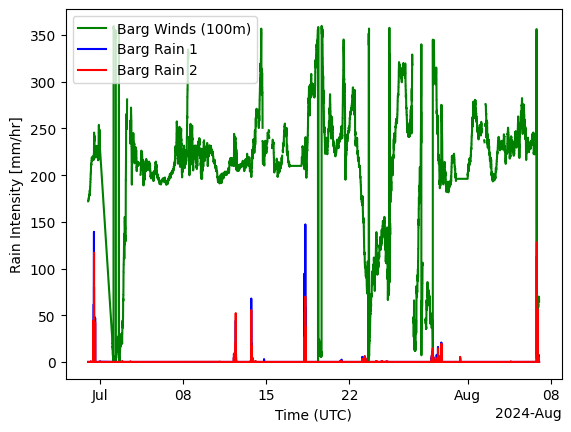

In [13]:
# Check All the Data
WD = datasets['Barg Winds']['wind_direction'].sel(height=100, method = 'nearest').sel(time=slice(None, "2024-08-06")).compute()

ds1 = datasets["Barg Rain 1"]['rain_intensity'].sel(time=slice(None, "2024-08-06"))   # Dataset
ds2 = datasets["Barg Rain 2"]['rain_intensity'].sel(time=slice(None, "2024-08-06"))   # Dataset

WD.plot(label="Barg Winds (100m)", color="green")
ds1.plot(label="Barg Rain 1", color="blue")
ds2.plot(label="Barg Rain 2", color="red")
plt.legend()
plt.show()

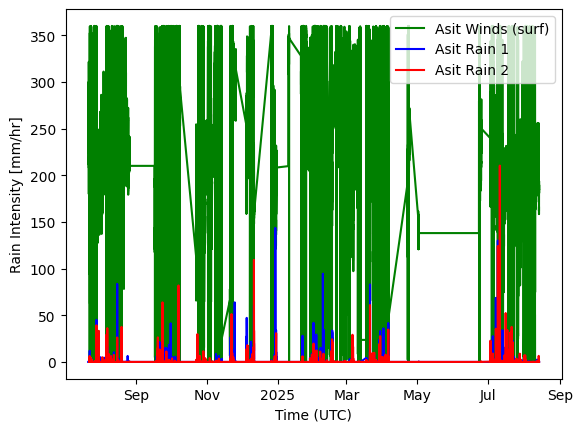

In [15]:
# Check All the Data
WD = datasets['Asit Winds']['surface_wind_direction'].compute()

ds1 = datasets["Asit Rain 1"]['rain_intensity']   # Dataset
ds2 = datasets["Asit Rain 2"]['rain_intensity']   # Dataset

WD.plot(label="Asit Winds (surf)", color="green")
ds1.plot(label="Asit Rain 1", color="blue")
ds2.plot(label="Asit Rain 2", color="red")
plt.legend()
plt.show()

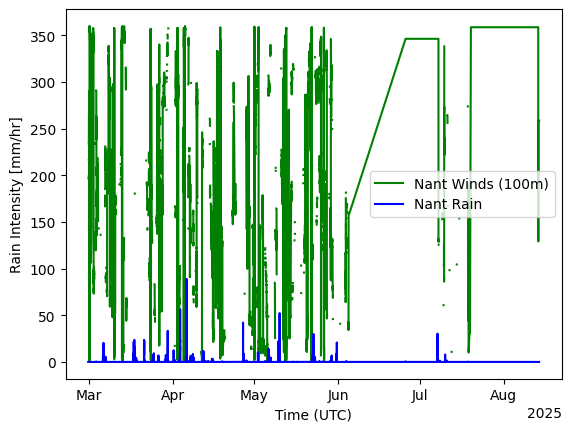

In [17]:
# Check All the Data
WD = datasets['Nant Winds']['wd'].sel(height=100, method = 'nearest').compute()

ds1 = datasets["Nant Rain"]['rain_intensity']   # Dataset

WD.plot(label="Nant Winds (100m)", color="green")
ds1.plot(label="Nant Rain", color="blue")
plt.legend()
plt.show()

## 5. Merge by Wind Direction

add the relevant lidar data to the dataset, and save

In [ ]:
WD = datasets['Barg Winds']['wind_direction'].sel(height=100, method = 'nearest').sel(time=slice(None, "2024-08-06")).compute()

ds1 = datasets["Barg Rain 1"].sel(time=slice(None, "2024-08-06"))   # Dataset
ds2 = datasets["Barg Rain 2"].sel(time=slice(None, "2024-08-06"))   # Dataset

# Boolean masks (True where condition met)
mask_ns = ((WD > 315) | (WD < 45) | ((WD > 135) & (WD < 225)))
mask_ew = (((WD > 45) & (WD < 135)) | ((WD > 225) & (WD < 315)))

new_ds = xr.where(mask_ns, ds1, xr.where(mask_ew, ds2, np.nan))
new_ds["rain_intensity_ns"] = ds1["rain_intensity"]
new_ds["rain_intensity_ew"] = ds2["rain_intensity"]
new_ds["wind_direction"] = WD
new_ds["wind_speed"] = datasets["Barg Winds"]["wind_speed"].sel(height=100, method='nearest').sel(time=slice(None, "2024-08-06")).compute()
new_ds["vertical_wind_speed"] = datasets["Barg Winds"]["vertical_wind_speed"].sel(height=100, method='nearest').sel(time=slice(None, "2024-08-06")).compute()

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True
)

# Top subplot
ds1["rain_intensity"].plot(
    ax=axes[0],
    label="Barg Rain 1 (NS)",
    color="blue"
)
axes[0].set_title("Barg Rain 1 (NS)")
axes[0].set_ylabel("Rain Intensity")
axes[0].legend()
axes[0].grid(True)

# Middle subplot
ds2["rain_intensity"].plot(
    ax=axes[1],
    label="Barg Rain 2 (EW)",
    color="orange"
)
axes[1].set_title("Barg Rain 2 (EW)")
axes[1].set_ylabel("Rain Intensity")
axes[1].legend()
axes[1].grid(True)

# Bottom subplot
new_ds["rain_intensity"].plot(
    ax=axes[2],
    label="Barg Rain (Filtered)",
    color="green",
    linewidth=2
)
axes[2].set_title("Barg Rain (Filtered by Wind Direction)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Rain Intensity")
axes[2].legend()
axes[2].grid(True)

fig.suptitle("BARG Rain Intensity", fontsize=16)
fig.tight_layout()
plt.show()

In [ ]:
new_ds 